In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

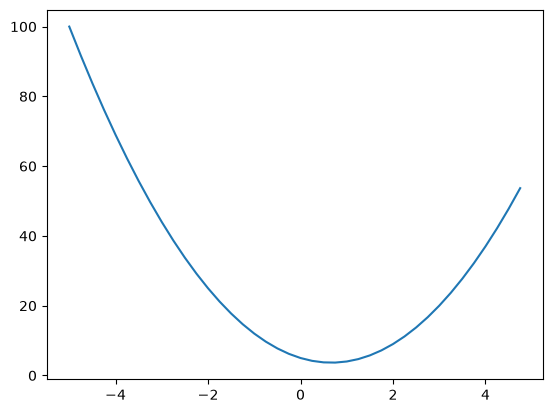

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))/h

2.999378523327323e-06

In [6]:
# a bit more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b+c

print('d1: ', d1)
print('d2: ', d2)
print('slope: ', (d2-d1)/h)

d1:  4.0
d2:  4.0001
slope:  0.9999999999976694


In [40]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):        # _ -> denotes private variables, that only class members can class
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    # kind of toString()
    def __repr__(self):
        return f"Value(data = {self.data})"

    # When a+b => python calls a.__add__(b)
    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        return self+(-other)

    def __neg__(self):
        return -1*self

    def __rsub__(self, other):
        return other + (-self)

    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += (other.data * out.grad)
            other.grad += (self.data * out.grad)
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other*(self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self*other**-1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        vis = set()
        def build_topo(v):
            if v not in vis:
                vis.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [41]:
a = Value(2.0)
# a + 1   # but 1+a doesnt work, python has __radd__
# 2*a
b = Value(4.0)
a-b

Value(data = -2.0)

In [42]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" %(n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect nl to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

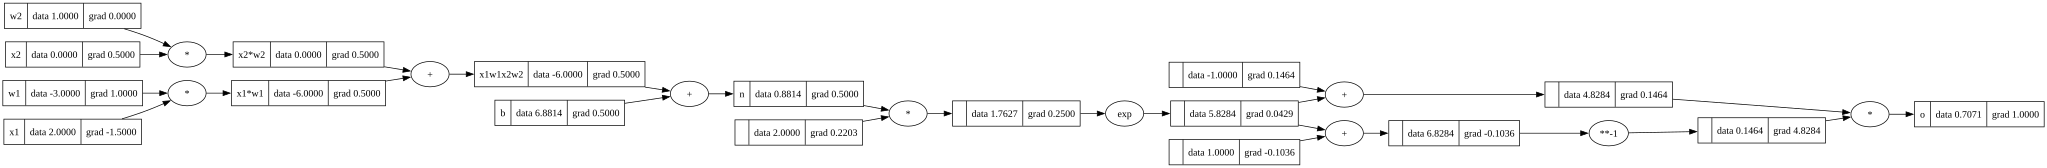

In [45]:
#inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); 

e = (2*n).exp()
o = (e-1)/(e+1)
o.backward()
o.label = 'o'
draw_dot(o)

# PyTorch

- how in pytorch its implemented / used in production

In [46]:
%pip install torch
import torch
import random

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
print(torch.__version__)

2.14.0+cpu


In [48]:
x1 = torch.Tensor([2.0]).double();                x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();                x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();               w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();                w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double();  b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('w1', w1.grad.item())
print('x1', x1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
w1 1.0000002567688737
x1 -1.5000003851533106


In [49]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [164]:
class Neuron:
    def __init__(self, nin):  # nin = number of i/ps
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
        
    def __call__(self, x):
        # w*x + b
        # zip(), pairing iterators
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
        
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
        
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
            return params
            
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [165]:
n.parameters()

[Value(data = 0.9051201567146935),
 Value(data = 1.068028927713019),
 Value(data = 0.4977912158299194),
 Value(data = 0.5291854700319494),
 Value(data = 0.951216647086378),
 Value(data = 0.3617005256729371),
 Value(data = -0.9005426174307753),
 Value(data = -0.09666075199387875),
 Value(data = 0.9253850955694629),
 Value(data = -0.09807909562048639),
 Value(data = 1.051094495950844),
 Value(data = -0.9910347125103619),
 Value(data = 0.675098944888997),
 Value(data = 0.5859495324962577)]

In [166]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data = 0.010967123692169376)

In [167]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]     #desired target

In [188]:
for k in range(20):
    # forward pass,taking guess
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))

    # zeroing the gradients: dont go like (1 step), (1+2) step, (1+2+3 steps), rather go 1, 2, 3
    for p in n.parameters():
        p.grad = 0.0
        
    # backward pass, find how bad is the initial guess
    loss.backward()

    # update, move forward in grad -> direction, since minimizing loss, learning rate got a '-' sign
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.005223673250248498
1 0.005199165098317143
2 0.00517488115124423
3 0.005150818376785445
4 0.005126973796797062
5 0.005103344486039878
6 0.005079927571014598
7 0.00505672022882781
8 0.00503371968608758
9 0.005010923217827551
10 0.004988328146459229
11 0.004965931840751031
12 0.00494373171483344
13 0.004921725227229987
14 0.004899909879912533
15 0.004878283217380521
16 0.004856842825763713
17 0.004835586331947266
18 0.004814511402718697
19 0.004793615743936309


In [189]:
ypred

[Value(data = 0.9741219319920593),
 Value(data = -0.9813504902729027),
 Value(data = -0.9555022327550948),
 Value(data = 0.9576197470834605)]